# **Baseline Logistic Regression Model vs Multi Layer Perceptron**

### **1. Load Dataset - Bank Churn dataset (Source: Kaggle)**

##### **Dataset Description**

*   The dataset used for this assignment is the Bank Churn dataset, which contains information about customers of a bank and whether they have exited (churned) or not.

*   It consists of approximately 10,000 samples with multiple features such as credit score, geography, gender, age, tenure, balance, number of products, and estimated salary.

*   The target variable is ‘Exited’, which indicates whether a customer has left the bank (1) or stayed (0).

*   This is a **binary classification problem**, as the goal is to predict whether a customer will churn or not based on the given features.

##### **Evaluation Metrics**

*   The primary evaluation metric chosen for this dataset is the **F1-score** because the dataset is imbalanced, with a higher number of non-churned customers compared to churned customers.

*    In such cases, accuracy can be misleading, as a model predicting only the majority class can still achieve high accuracy.

*    In the context of bank churn prediction, **recall** is particularly important because failing to identify a customer who is likely to churn can result in loss of business.

##### **Mount the Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##### **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import time

##### **Data Readin**

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Bits Pilani WILP/Sem 1/DNN/Assignment/Bank_Churn.csv")
print("Data Shape:", data.shape)
data.head(20)

Data Shape: (10000, 13)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


### **2. Data Cleansing**

In [4]:
data.CustomerId = data['CustomerId'].astype(str)

### **3. Data Quality Checks**

In [5]:
#Checking missing values

data.isna().count() # No missing value in any of the columns

,0
CustomerId,10000
Surname,10000
CreditScore,10000
Geography,10000
Gender,10000
Age,10000
Tenure,10000
Balance,10000
NumOfProducts,10000
HasCrCard,10000


In [6]:
# Checking duplicate records.

print("Total No. of records:", data.shape[0])

data_1 = data.drop_duplicates()
print("Number of records after removing duplicates:", data_1.shape[0]) # No Duplicates in the data

Total No. of records: 10000
Number of records after removing duplicates: 10000


In [7]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Check if Age is less than 18 or greater than 100. If records exist, then further preprocessing steps are needed to handle the data.
print("No. of records with Age out of range:", data[(data.Age<18) | (data.Age>100)].shape[0])

No. of records with Age out of range: 0


In [9]:
data.groupby(['Geography', 'Exited'])['CustomerId'].count()

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: CustomerId, dtype: int64

In [10]:
data.groupby(['Gender', 'Exited'])['CustomerId'].count()

Gender  Exited
Female  0         3404
        1         1139
Male    0         4559
        1          898
Name: CustomerId, dtype: int64

In [11]:
data.groupby(['NumOfProducts', 'Exited'])['CustomerId'].count()

NumOfProducts  Exited
1              0         3675
               1         1409
2              0         4242
               1          348
3              0           46
               1          220
4              1           60
Name: CustomerId, dtype: int64

In [12]:
data.groupby(['HasCrCard', 'Exited'])['CustomerId'].count()

HasCrCard  Exited
0          0         2332
           1          613
1          0         5631
           1         1424
Name: CustomerId, dtype: int64

### **4. Exploratory Data Analysis**

,Exited,CustomerId
0,0,7963
1,1,2037


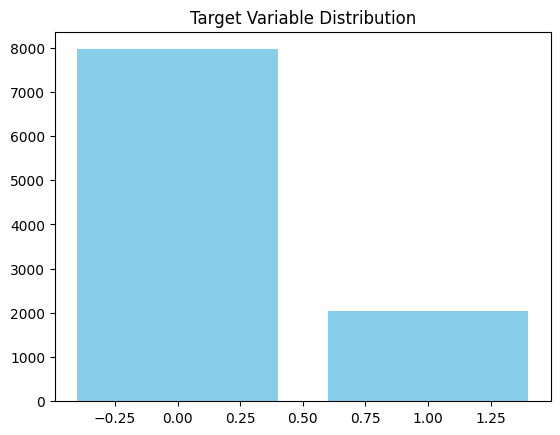

In [13]:
# Target Variable Distribution - Conclusion: Data is not balanced

Exited_summ = pd.DataFrame(data.groupby(['Exited'])['CustomerId'].count()).reset_index()
display(Exited_summ)

categories = Exited_summ['Exited']
values = Exited_summ['CustomerId']

plt.bar(categories, values, color='skyblue')
plt.title('Target Variable Distribution')

plt.show()

In [14]:
# Using IQR Method to find outliers based on 'Balance' - Conclusion: No outlier noted

Q1 = data['Balance'].quantile(0.25)
Q3 = data['Balance'].quantile(0.75)
IQR = Q3 - Q1

outliers = data[(data['Balance'] < Q1 - 1.5*IQR) |
              (data['Balance'] > Q3 + 1.5*IQR)]

print("Number of outliers:\n",outliers.count())

Number of outliers:
 CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


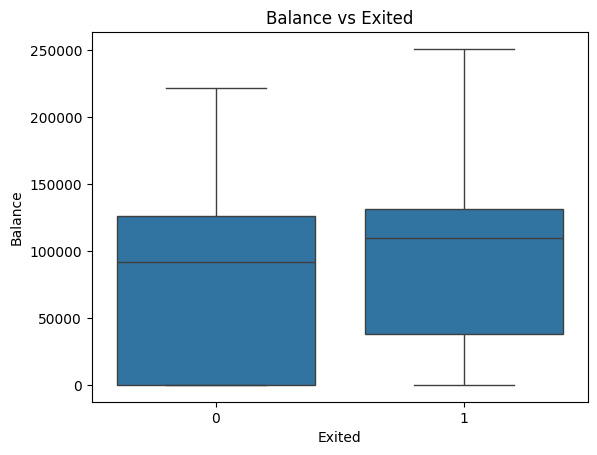

In [15]:
sns.boxplot(x='Exited', y='Balance', data=data)
plt.title('Balance vs Exited')
plt.show()

# Psitively skewed population
# Since the box plot is almost completely overlapping for both 0 and 1, therefore this field does not impact the target variable.

In [16]:
# Using IQR Method to find outliers based on 'EstimatedSalary' - Conclusion: No outlier noted.

Q1 = data['EstimatedSalary'].quantile(0.25)
Q3 = data['EstimatedSalary'].quantile(0.75)
IQR = Q3 - Q1

outliers = data[(data['EstimatedSalary'] < Q1 - 1.5*IQR) |
              (data['EstimatedSalary'] > Q3 + 1.5*IQR)]

print("Number of outliers:\n",outliers.count())

Number of outliers:
 CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


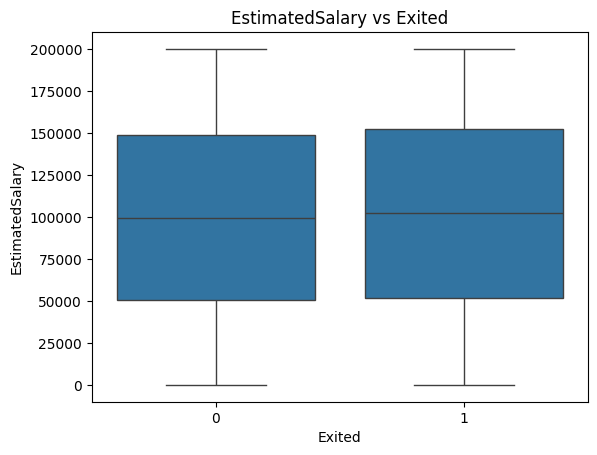

In [17]:
sns.boxplot(x='Exited', y='EstimatedSalary', data=data)
plt.title('EstimatedSalary vs Exited')
plt.show()

# Evenly distributed across the population.
# Since the box plot is almost completely overlapping for both 0 and 1, therefore this field does not impact the target variable.

In [18]:
# Binning Numerical columns except Balance & EstimatedSalary

# Credit Score
data['CreditScore_bins'] = pd.cut(data['CreditScore'], bins=5)

# Tenure
data['Tenure_bins'] = pd.cut(data['Tenure'], bins=5)

# Age
edges = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
names = ['18-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']

data['Age_bins'] = pd.cut(data['Age'], bins=edges, labels=names)

data.head(10)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScore_bins,Tenure_bins,Age_bins
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,"(550.0, 650.0]","(-0.01, 2.0]",40-50
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,"(550.0, 650.0]","(-0.01, 2.0]",40-50
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,"(450.0, 550.0]","(6.0, 8.0]",40-50
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,"(650.0, 750.0]","(-0.01, 2.0]",30-40
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,"(750.0, 850.0]","(-0.01, 2.0]",40-50
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,"(550.0, 650.0]","(6.0, 8.0]",40-50
6,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,"(750.0, 850.0]","(6.0, 8.0]",40-50
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,"(349.5, 450.0]","(2.0, 4.0]",20-30
8,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,"(450.0, 550.0]","(2.0, 4.0]",40-50
9,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,"(650.0, 750.0]","(-0.01, 2.0]",20-30


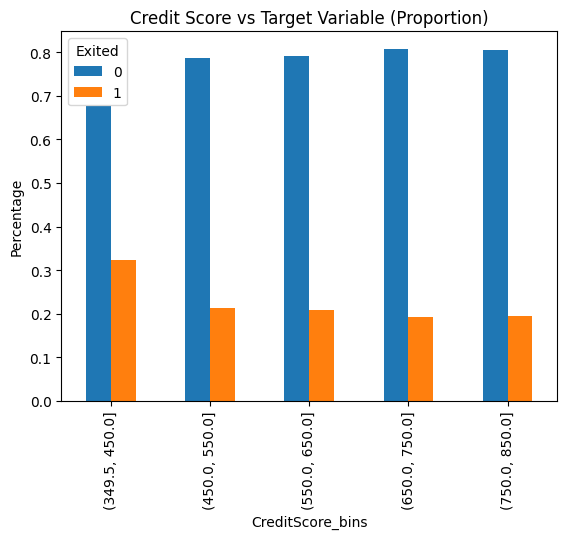

In [19]:
# Using proportion chart for categorical Features vs Target Variable since data is not distributed evenly.
# Credit Score vs Target Variable - Conclusion: Little to no dependency

prop_df = pd.crosstab(data['CreditScore_bins'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('Credit Score vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

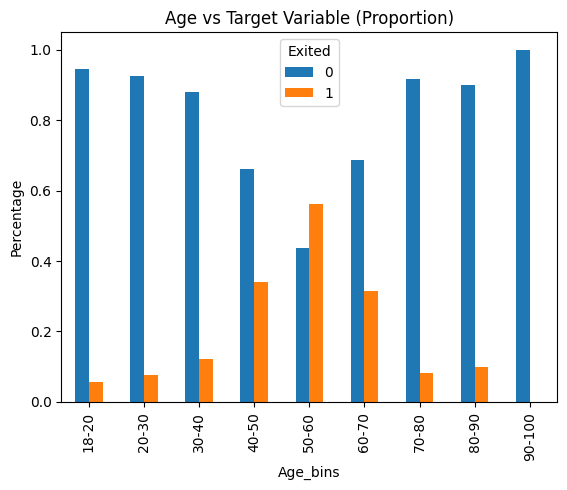

In [20]:
# Age vs Target Variable - Coonclusion: Has dependency

prop_df = pd.crosstab(data['Age_bins'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('Age vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

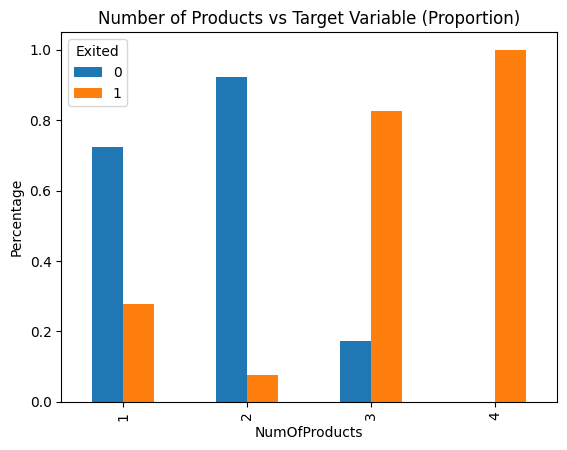

In [21]:
# Number of Products vs Target Variable - Conclusion: Has high dependency

prop_df = pd.crosstab(data['NumOfProducts'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('Number of Products vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

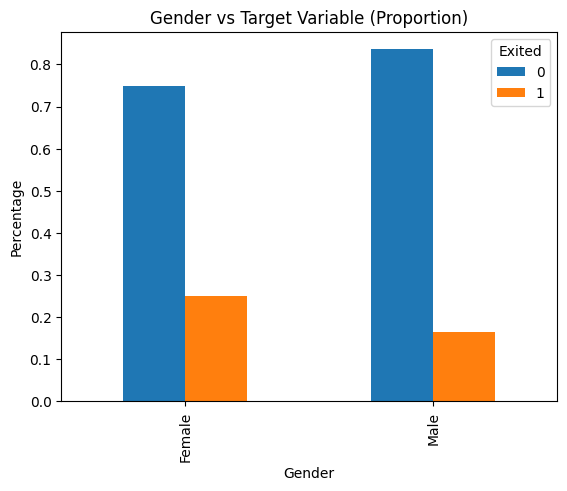

In [22]:
# Gender vs Target Variable - Conclusion: Little to no dependency

prop_df = pd.crosstab(data['Gender'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('Gender vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

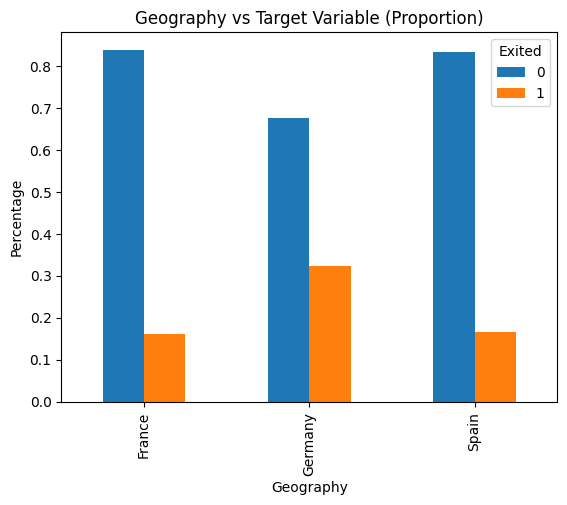

In [23]:
# Geography vs Target Variable - Conclusion: Slight dependency

prop_df = pd.crosstab(data['Geography'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('Geography vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

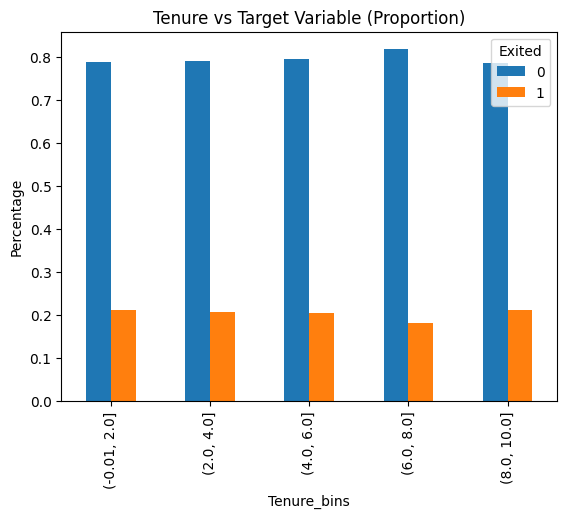

In [24]:
# Tenure vs Target Variable - Conclusion: Little to no dependency

prop_df = pd.crosstab(data['Tenure_bins'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('Tenure vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

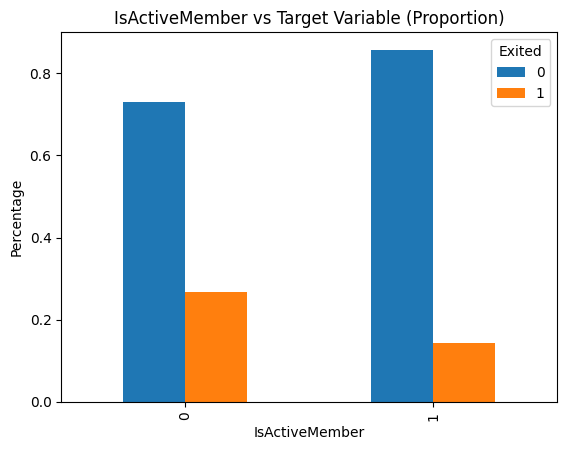

In [25]:
# IsActiveMember vs Target Variable - Conclusion: Slight dependency

prop_df = pd.crosstab(data['IsActiveMember'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('IsActiveMember vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

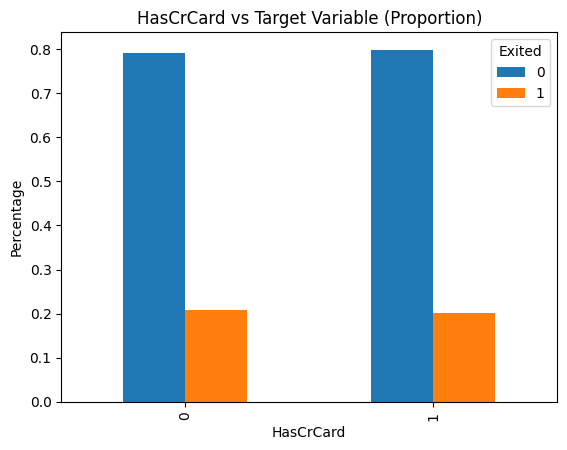

In [26]:
# HasCrCard vs Target Variable - Conclusion: No dependency

prop_df = pd.crosstab(data['HasCrCard'], data['Exited'], normalize='index')

prop_df.plot(kind='bar')
plt.title('HasCrCard vs Target Variable (Proportion)')
plt.ylabel('Percentage')
plt.show()

<Axes: >

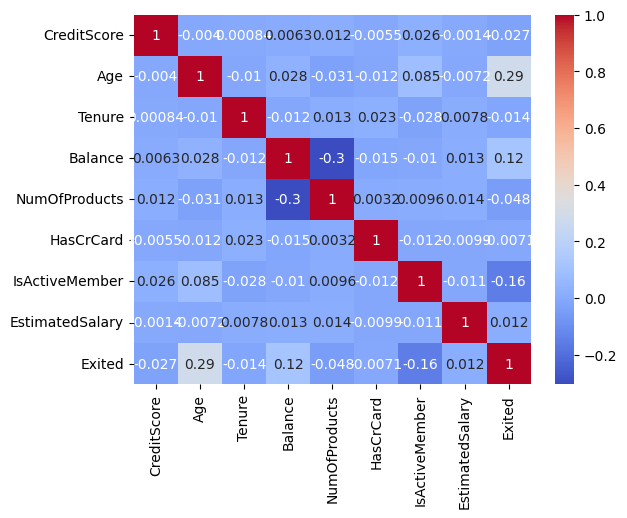

In [27]:
# Correlation Analysis
# Conclusion:
  # Age has maximum correlation with Target Variable
  # Most features have weak correlation with Target variable
  # isActiveMember has negative correlation: Implies that active members are less likely to churn.
  # No feature pair has correlation > 0.8: Implies no multicollinearity issue

sns.heatmap(data[['CreditScore', 'Age',	'Tenure',	'Balance',	'NumOfProducts',	'HasCrCard',	'IsActiveMember',	'EstimatedSalary', 'Exited']].corr(), annot=True, cmap='coolwarm')

### **5. Data Preprocessing**

##### **Checking Class imbalance**

In [28]:
data['Exited'].value_counts(normalize=True)

# Conclusion: 20% customers churn: highly imbalanced dataset
# Implies that the model may be biased toward non-churn customers
# Due to this, we were getting models that always predicted 0. Had High accuracy but 0 precision, recall and f1 score.

,proportion
Exited,
0,0.7963
1,0.2037


In [29]:
# Implementing Oversampling of minority class in the data to improve other evaluation metrics

# Separating majority and classes
data_majority = data[data['Exited'] == 0]
data_minority = data[data['Exited'] == 1]

# Upsample minority
data_minority_upsampled = data_minority.sample(
    n=len(data_majority),
    replace=True,
    random_state=42
)

# Combine
data_balanced = pd.concat([data_majority, data_minority_upsampled])

##### **Train Test Split**

In [30]:
X = data_balanced[['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']]
y = data_balanced[['Exited']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

##### **Encoding Categorical columns**

In [31]:
# Label encoding for 'Gender' column

le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender']) # Fitting Train Data
X_test['Gender'] = le.transform(X_test['Gender']) # Transforming Test Data

In [32]:
# One-hot encoding for 'Geography' column

X_train = pd.get_dummies(X_train, columns=['Geography'], drop_first=True) # Fitting Train Data
X_test = pd.get_dummies(X_test, columns=['Geography'], drop_first=True) # Transforming Test Data

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [33]:
X_train.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
3560,817,1,44,8,0.00,1,0,0,65501.91,False,False
2104,768,1,42,5,0.00,3,0,0,60686.40,False,False
53,655,1,41,8,125561.97,1,0,0,164040.94,True,False
9403,638,0,36,6,0.00,1,1,0,164247.51,False,False
3279,652,1,37,7,0.00,2,1,0,68789.93,False,True
5642,782,0,41,4,0.00,1,1,0,132943.88,False,True
9949,850,0,47,9,137301.87,1,1,0,44351.77,False,False
4403,602,0,43,2,113641.49,4,1,0,115116.35,True,False
912,545,0,32,4,0.00,1,1,0,94739.20,False,True
5947,656,0,45,7,145933.27,1,1,1,199392.14,False,False


##### **Scaling Features**

In [34]:
scaler = StandardScaler()

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [35]:
X_train.head(10)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
3560,1.744581,1,0.264949,1.022602,-1.333994,-0.760682,0,0,-0.604746,False,False
2104,1.241303,1,0.076102,0.000882,-1.333994,2.226247,0,0,-0.688406,False,False
53,0.080684,1,-0.018321,1.022602,0.708985,-0.760682,0,0,1.107189,True,False
9403,-0.093923,0,-0.490438,0.341455,-1.333994,-0.760682,1,0,1.110778,False,False
3279,0.049871,1,-0.396015,0.682029,-1.333994,0.732782,1,0,-0.547623,False,True
5642,1.385097,0,-0.018321,-0.339691,-1.333994,-0.760682,1,0,0.566935,False,True
9949,2.083523,0,0.548218,1.363175,0.900001,-0.760682,1,0,-0.972191,False,False
4403,-0.463678,0,0.170525,-1.020838,0.515031,3.719711,1,0,0.257214,True,False
912,-1.049123,0,-0.868131,-0.339691,-1.333994,-0.760682,1,0,-0.096802,False,True
5947,0.090955,0,0.359372,0.682029,1.040440,-0.760682,1,1,1.721351,False,False


### **6. Baseline Model**

##### **Correctiong data types for model calculations**

In [36]:
X_train.dtypes

,0
CreditScore,float64
Gender,int64
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Geography_Germany,bool


In [37]:
X_train['Gender'] = X_train['Gender'].astype('float64')
X_train['HasCrCard'] = X_train['HasCrCard'].astype('float64')
X_train['IsActiveMember'] = X_train['IsActiveMember'].astype('float64')
X_train['Geography_Germany'] = X_train['Geography_Germany'].astype('float64')
X_train['Geography_Spain'] = X_train['Geography_Spain'].astype('float64')

##### **Implementing logistic regression**

In [38]:
class LogisticRegressionScratch:

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    # Sigmoid Function
    def sigmoid(self, z):
        # print(type(z))
        # print(z)
        # print(z.dtype if hasattr(z, 'dtype') else "No dtype")
        z = np.array(z, dtype=float)
        return 1 / (1 + np.exp(-z))

    # Loss Function (Binary Cross Entropy)
    def compute_loss(self, y, y_pred):
        epsilon = 1e-15  # avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        loss = -np.mean(
            y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)
        )
        return loss

    # Fit Function (Training)
    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        y['Exited'] = y['Exited'].astype('float64')
        y = np.array(y['Exited'])

        # Gradient Descent
        for i in range(self.n_iters):
            start_time = time.time()
            # Forward pass
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update weights
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Optional: print loss
            if i % 100 == 0:
                print(f"Iteration {i}, Loss: {loss:.4f}")

        self.training_time = time.time() - start_time

    # Predict probabilities
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    # Predict class (0 or 1)
    def predict(self, X, threshold=0.5):
        y_probs = self.predict_proba(X)
        return (y_probs >= threshold).astype(int)

Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.6589
Iteration 200, Loss: 0.6378
Iteration 300, Loss: 0.6242
Iteration 400, Loss: 0.6151
Iteration 500, Loss: 0.6087
Iteration 600, Loss: 0.6040
Iteration 700, Loss: 0.6004
Iteration 800, Loss: 0.5976
Iteration 900, Loss: 0.5953


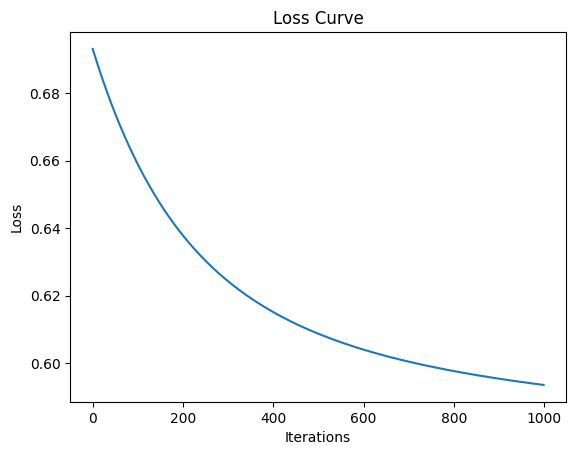

In [39]:
# Initialize model
model = LogisticRegressionScratch(lr=0.01, n_iters=1000)

# Train model
model.fit(X_train, y_train)

# Generate Predictions
y_pred = model.predict(X_test)

# Loss Curve
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

##### **Accuracy calculation**

In [40]:
baseline_accuracy = np.mean(np.array(y_pred) == np.array(y_test))
print("Accuracy:", baseline_accuracy)

Accuracy: 0.5004303195595609


### **7. Multilayer Perceptron**

In [41]:
class MLP:

    def __init__(self, layers, lr=0.01, n_iters=1000):
        self.layers = layers
        self.lr = lr
        self.n_iters = n_iters
        self.parameters = {}
        self.loss_history = []

    # Initialize weights and biases
    def initialize_parameters(self):
        np.random.seed(42)
        for i in range(1, len(self.layers)):
            self.parameters['W' + str(i)] = np.random.randn(
                self.layers[i-1], self.layers[i]
            ) * 0.01
            self.parameters['b' + str(i)] = np.zeros((1, self.layers[i]))

    # Activation functions
    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        Z = np.array(Z, dtype=float)
        return 1 / (1 + np.exp(-Z))

    # Loss
    def compute_loss(self, y, y_hat):
        epsilon = 1e-15
        y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    # Forward Propagation
    def forward_propagation(self, X):
        cache = {}
        A = X

        L = len(self.layers) - 1

        for i in range(1, L):
            Z = np.dot(A, self.parameters['W' + str(i)]) + self.parameters['b' + str(i)]
            A = self.relu(Z)
            cache['Z' + str(i)] = Z
            cache['A' + str(i)] = A

        # Output layer (sigmoid)
        ZL = np.dot(A, self.parameters['W' + str(L)]) + self.parameters['b' + str(L)]
        AL = self.sigmoid(ZL)

        cache['Z' + str(L)] = ZL
        cache['A' + str(L)] = AL

        return AL, cache

    # Backward Propagation
    def backward_propagation(self, X, y, cache):
        grads = {}
        m = X.shape[0]
        L = len(self.layers) - 1

        y = y.reshape(-1, 1)
        AL = cache['A' + str(L)]

        # Output layer gradient
        dZL = AL - y
        A_prev = cache['A' + str(L-1)] if L > 1 else X

        grads['dW' + str(L)] = (1/m) * np.dot(A_prev.T, dZL)
        grads['db' + str(L)] = (1/m) * np.sum(dZL, axis=0, keepdims=True)

        dA_prev = np.dot(dZL, self.parameters['W' + str(L)].T)

        # Hidden layers
        for i in reversed(range(1, L)):
            dZ = dA_prev * self.relu_derivative(cache['Z' + str(i)])

            A_prev = X if i == 1 else cache['A' + str(i-1)]

            grads['dW' + str(i)] = (1/m) * np.dot(A_prev.T, dZ)
            grads['db' + str(i)] = (1/m) * np.sum(dZ, axis=0, keepdims=True)

            dA_prev = np.dot(dZ, self.parameters['W' + str(i)].T)

        return grads

    # Update weights
    def update_parameters(self, grads):
        L = len(self.layers) - 1
        for i in range(1, L+1):
            self.parameters['W' + str(i)] -= self.lr * grads['dW' + str(i)]
            self.parameters['b' + str(i)] -= self.lr * grads['db' + str(i)]

    # Training
    def fit(self, X, y):
        self.initialize_parameters()
        start_time = time.time()

        y['Exited'] = y['Exited'].astype('float64')
        y = np.array(y['Exited'])

        for i in range(self.n_iters):
            # Forward
            y_hat, cache = self.forward_propagation(X)

            # Loss
            loss = self.compute_loss(y.reshape(-1,1), y_hat)
            self.loss_history.append(loss)

            # Backward
            grads = self.backward_propagation(X, y, cache)

            # Update
            self.update_parameters(grads)

            if i % 100 == 0:
                print(f"Iteration {i}, Loss: {loss:.4f}")

        self.training_time = time.time() - start_time

    # Predict
    def predict(self, X):
        y_hat, _ = self.forward_propagation(X)
        return (y_hat >= 0.5).astype(int)

Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.6931
Iteration 200, Loss: 0.6931
Iteration 300, Loss: 0.6931
Iteration 400, Loss: 0.6931
Iteration 500, Loss: 0.6931
Iteration 600, Loss: 0.6931
Iteration 700, Loss: 0.6931
Iteration 800, Loss: 0.6931
Iteration 900, Loss: 0.6931


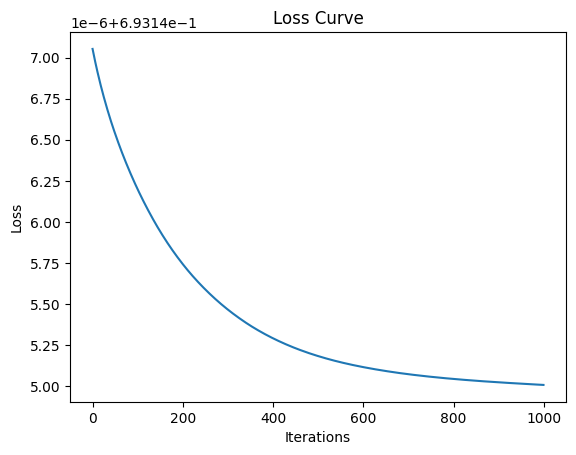

In [42]:
mlp = MLP(layers=[X_train.shape[1], 8, 4, 1], lr=0.01, n_iters=1000)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

# Loss Curve
plt.plot(mlp.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

In [43]:
accuracy = np.mean(y_pred_mlp.flatten() == np.array(y_test))
print("MLP Accuracy:", accuracy)

MLP Accuracy: 0.4962335216572505


In [44]:
def get_assignment_results():
    results = {
        "dataset_name": "Bank Churn",
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "problem_type": "Binary Classification",
        "primary_metric": "Accuracy",

        "baseline_model": {
            "model": "Logistic Regression (Scratch)",
            "test_accuracy": baseline_accuracy,
            "training_time": model.training_time
        },

        "mlp_model": {
            "architecture": mlp.layers,
            "test_accuracy": accuracy,
            "training_time": mlp.training_time
        }
    }

    return results

### **8. Implementing get_assignment_results()**

In [45]:
get_assignment_results()

{'dataset_name': 'Bank Churn',
 'n_samples': 15926,
 'n_features': 10,
 'problem_type': 'Binary Classification',
 'primary_metric': 'Accuracy',
 'baseline_model': {'model': 'Logistic Regression (Scratch)',
  'test_accuracy': np.float64(0.5004303195595609),
  'training_time': 0.0020294189453125},
 'mlp_model': {'architecture': [11, 8, 4, 1],
  'test_accuracy': np.float64(0.4962335216572505),
  'training_time': 8.851737260818481}}

### **9. Evaluations and Comparison**

##### **For Baseline Model**

In [46]:
TP = np.sum((np.array(y_test) == 1) & (np.array(y_pred) == 1))
TN = np.sum((np.array(y_test) == 0) & (np.array(y_pred) == 0))
FP = np.sum((np.array(y_test) == 0) & (np.array(y_pred) == 1))
FN = np.sum((np.array(y_test) == 1) & (np.array(y_pred) == 0))

# Accuracy
baseline_acc = (TP + TN) / (TP + TN + FP + FN)

# Precision
baseline_prec = TP / (TP + FP + 1e-10)

# Recall
baseline_rec = TP / (TP + FN + 1e-10)

# F1 Score
baseline_f1 = 2 * (baseline_prec * baseline_rec) / (baseline_prec + baseline_rec + 1e-10)

print("Accuracy:", baseline_acc)
print("Precision:", baseline_prec)
print("Recall:", baseline_rec)
print("F1 Score:", baseline_f1)

Accuracy: 0.5004303195595609
Precision: 0.4962335216572505
Recall: 0.4428750784682988
F1 Score: 0.4680384351496136


##### **For Multilayer Perceptron**

In [47]:
TP = np.sum((np.array(y_test) == 1) & (np.array(y_pred_mlp) == 1))
TN = np.sum((np.array(y_test) == 0) & (np.array(y_pred_mlp) == 0))
FP = np.sum((np.array(y_test) == 0) & (np.array(y_pred_mlp) == 1))
FN = np.sum((np.array(y_test) == 1) & (np.array(y_pred_mlp) == 0))

# Accuracy
mlp_acc = (TP + TN) / (TP + TN + FP + FN)

# Precision
mlp_prec = TP / (TP + FP + 1e-10)

# Recall
mlp_rec = TP / (TP + FN + 1e-10)

# F1 Score
mlp_f1 = 2 * (mlp_prec * mlp_rec) / (mlp_prec + mlp_rec + 1e-10)

print("Accuracy:", mlp_acc)
print("Precision:", mlp_prec)
print("Recall:", mlp_rec)
print("F1 Score:", mlp_f1)

Accuracy: 0.4962335216572505
Precision: 0.4962335216572349
Recall: 0.9999999999999367
F1 Score: 0.6633102579795546


In [48]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
mlp_scores = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]

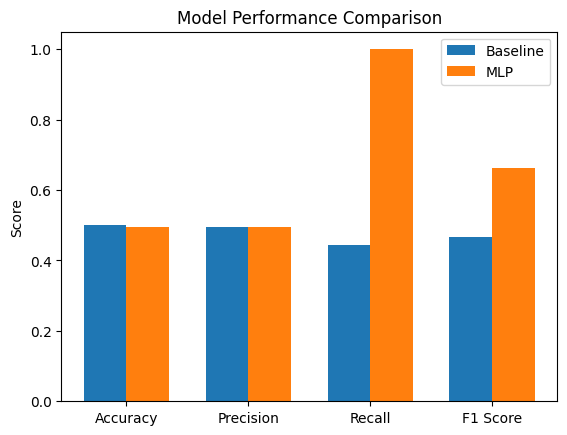

In [49]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(metrics))  # positions
width = 0.35  # bar width

plt.figure()

plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()

plt.show()

### **10. Analysis**



*   The Multilayer Perceptron model provides better results compared to the baseline logistic regression model in terms of recall and F1-score, while having similar accuracy.
*   The most notable improvement is in recall, where the MLP achieved ~1.0 compared to 0.44 for the baseline, indicating that the MLP successfully identified almost all positive (churn) cases.

*   However, the MLP’s precision (~0.496) is similar to the baseline, suggesting it predicts many false positives, implying that the MLP is biased toward predicting the positive class.

*   In terms of computational cost, the MLP is more expensive due to multiple layers and backpropagation, whereas logistic regression is simpler and faster,as indicated by training time of both the models.

*   Key Challenge: Handling class imbalance, which significantly impacted model behavior. Initially without correcting class imbalance, both the model predicted majority class only.

Overall, the MLP performed better for detecting churn (higher recall and F1),
but at the cost of increased false positives and computational complexity.

### **End of Script**